# Credit Card Application Fraud Detection using Machine Learning

**Berkeley HAAS Professional Certificate in ML & AI: Professional Certificate in Machine Learning and Artificial Intelligence - Capstone Project**

| | |
|---|---|
| **Domain** | FinTech / Financial Risk Management |
| **Author** | Sumit Saha |
| **Date** | March 2026 |
| **Dataset** | [Kaggle — Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud) |


## Executive Summary

This project builds an end-to-end machine learning pipeline to detect fraudulent credit-card transactions. The dataset contains 284,807 transactions of which only 492 (0.17%) are fraudulent, presenting a severe class-imbalance challenge.

We compare **Logistic Regression**, **Random Forest**, **XGBoost** and a simple **Neural Network**, optimising for **Recall** and **AUPRC** — the metrics that matter most in fraud detection where missing a fraud (false negative) is far costlier than flagging a legitimate transaction.

## 1. Imports

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os, json
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    precision_recall_curve, average_precision_score,
    roc_curve, f1_score, recall_score, precision_score, accuracy_score
)
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier


# Styling
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("husl")
COLORS = {"primary": "#1B3A5C", "accent": "#E74C3C", "secondary": "#2ECC71",
           "warn": "#F39C12", "bg": "#F8F9FA"}
PLOT_DIR = 'plots'

import os
os.makedirs(PLOT_DIR, exist_ok=True)
print('Libraries loaded successfully.')

print("=" * 72)
print("CREDIT CARD FRAUD DETECTION — CAPSTONE PROJECT")
print("=" * 72)
print(f"\nAll Libraries successfully loaded.")

Libraries loaded successfully.
CREDIT CARD FRAUD DETECTION — CAPSTONE PROJECT

All Libraries successfully loaded.


## 2. Load Dataset

Load the Kaggle Credit Card Fraud Detection dataset from the `data/` folder. The dataset has 284,807 transactions with 30 features (V1–V28 from PCA, plus Time and Amount) and a binary `Class` label.

In [7]:
# Load the real Kaggle dataset from the data/ folder
df = pd.read_csv("data/creditcard.csv")

N_LEGIT = (df["Class"] == 0).sum()
N_FRAUD = (df["Class"] == 1).sum()
N_TOTAL = len(df)

print(f"Dataset shape: {df.shape}")
print(f"Legitimate transactions: {N_LEGIT:,}")
print(f"Fraudulent transactions: {N_FRAUD:,}")
print(f"Fraud ratio: {df['Class'].mean()*100:.3f}%")
df.head()

Dataset shape: (284807, 31)
Legitimate transactions: 284,315
Fraudulent transactions: 492
Fraud ratio: 0.173%


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [8]:
# Data types and info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [16]:
# Basic statistics for numeric columns
print(f"Most of the fields are PCA transformed hence describing only 2 fields")
df[["Amount","Time"]].describe().round(2)

Most of the fields are PCA transformed hence describing only 2 fields


,Amount,Time
count,284807.00,284807.00
mean,88.35,94813.86
std,250.12,47488.15
min,0.00,0.00
25%,5.60,54201.50
50%,22.00,84692.00
75%,77.16,139320.50
max,25691.16,172792.00


In [23]:
# Check missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Count': missing, 'Percentage': missing_pct})
missing_df = missing_df[missing_df['Count'] > 0].sort_values('Percentage', ascending=False)
print(f"Missing Values Summary:\n{missing_df}" if not missing_df.empty else "No missing data")

No missing data


## 3. Exploratory Data Analysis

### 3a. Class Distribution, Amount & Time

Mean Amount of Valid Transation: $88.29 and Fraud Transaction: $122.21
Highest fraud amount: $2125.87
Highest legitimate amount: $25691.16


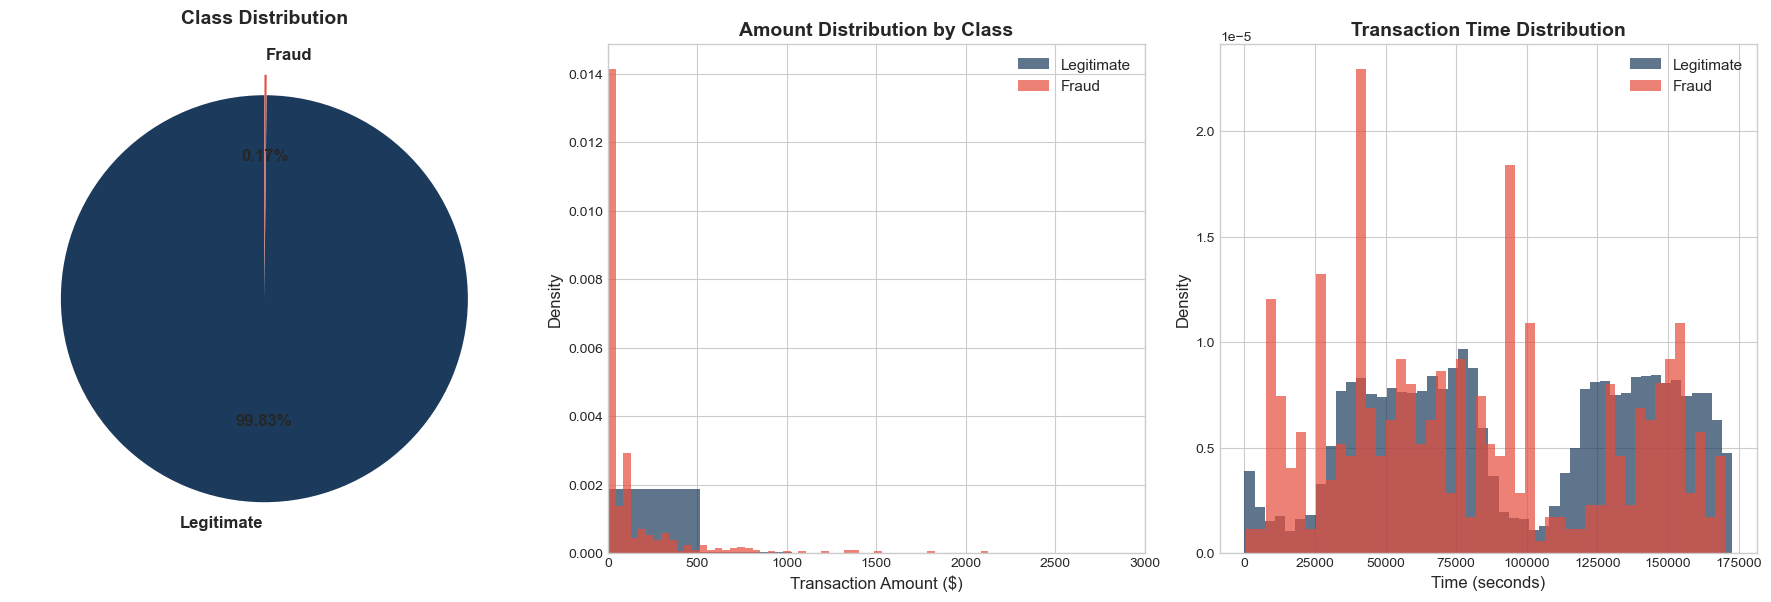

In [50]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Class balance
counts = df["Class"].value_counts()
colors_pie = [COLORS["primary"], COLORS["accent"]]
axes[0].pie(counts, labels=["Legitimate", "Fraud"], autopct="%1.2f%%",
            colors=colors_pie, startangle=90, explode=(0, 0.1),
            textprops={"fontsize": 12, "fontweight": "bold"})
axes[0].set_title("Class Distribution", fontsize=14, fontweight="bold", pad=15)

# Amount distribution
for cls, label, color in [(0, "Legitimate", COLORS["primary"]), (1, "Fraud", COLORS["accent"])]:
    subset = df[df["Class"] == cls]["Amount"]
    axes[1].hist(subset, bins=50, alpha=0.7, label=label, color=color, density=True)
axes[1].set_xlabel("Transaction Amount ($)", fontsize=12)
axes[1].set_ylabel("Density", fontsize=12)
axes[1].set_title("Amount Distribution by Class", fontsize=14, fontweight="bold")
axes[1].legend(fontsize=11)
axes[1].set_xlim(0, 3000)
print(f"Mean Amount of Valid Transation: ${df[df['Class'] == 0]['Amount'].mean().round(2)} and Fraud Transaction: ${df[df['Class'] == 1]['Amount'].mean().round(2)}")
print(f"Highest fraud amount: ${df[df['Class'] == 1]['Amount'].max():.2f}")
print(f"Highest legitimate amount: ${df[df['Class'] == 0]['Amount'].max():.2f}")

# Time distribution
for cls, label, color in [(0, "Legitimate", COLORS["primary"]), (1, "Fraud", COLORS["accent"])]:
    subset = df[df["Class"] == cls]["Time"]
    axes[2].hist(subset, bins=48, alpha=0.7, label=label, color=color, density=True)
axes[2].set_xlabel("Time (seconds)", fontsize=12)
axes[2].set_ylabel("Density", fontsize=12)
axes[2].set_title("Transaction Time Distribution", fontsize=14, fontweight="bold")
axes[2].legend(fontsize=11)

plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/Class balance_Amount distribution_Transaction distribution.png', dpi=150, bbox_inches='tight')
plt.show()

Together, these three plots establish that fraud is rare, tends to involve slightly higher amounts, and occurs at unusual times - all of which justify the feature engineering and modeling choices made later in the project.

### 3b. Correlation Heatmap of Key Features

In [51]:
# Find top features correlated with fraud
corr_with_class = df.corr()["Class"].drop("Class").abs().sort_values(ascending=False)
top_cols = corr_with_class.head(15).index.tolist() + ["Amount", "Class","Time"]
print(corr_with_class.head(15))

V17    0.326481
V14    0.302544
V12    0.260593
V10    0.216883
V16    0.196539
V3     0.192961
V7     0.187257
V11    0.154876
V4     0.133447
V18    0.111485
V1     0.101347
V9     0.097733
V5     0.094974
V2     0.091289
V6     0.043643
Name: Class, dtype: float64


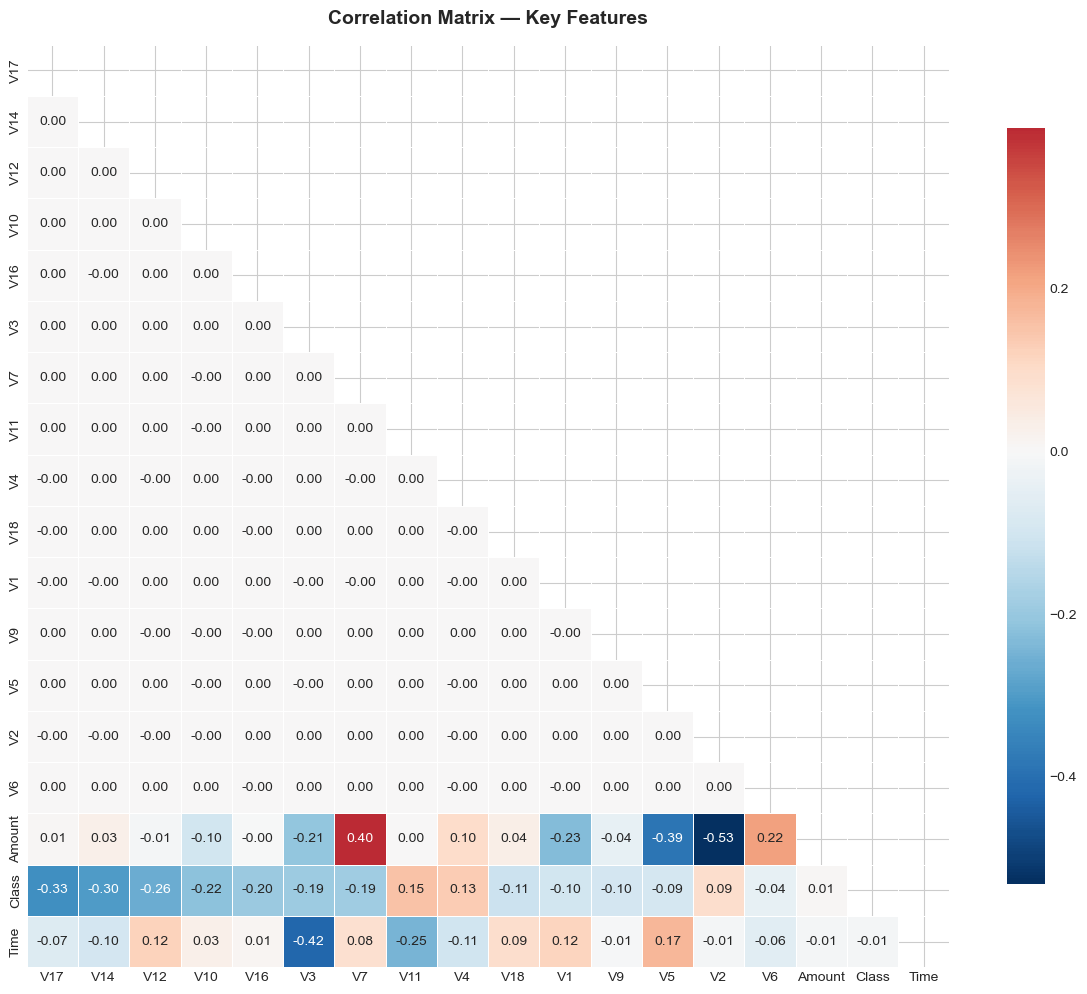

In [59]:
fig, ax = plt.subplots(figsize=(12, 10))
corr = df[top_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, ax=ax, square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.8})
ax.set_title("Correlation Matrix — Key Features", fontsize=14, fontweight="bold", pad=15)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/Correlation Matrix.png', dpi=150, bbox_inches='tight')
plt.show()

### 3c. Box Plots of Key Features by Class

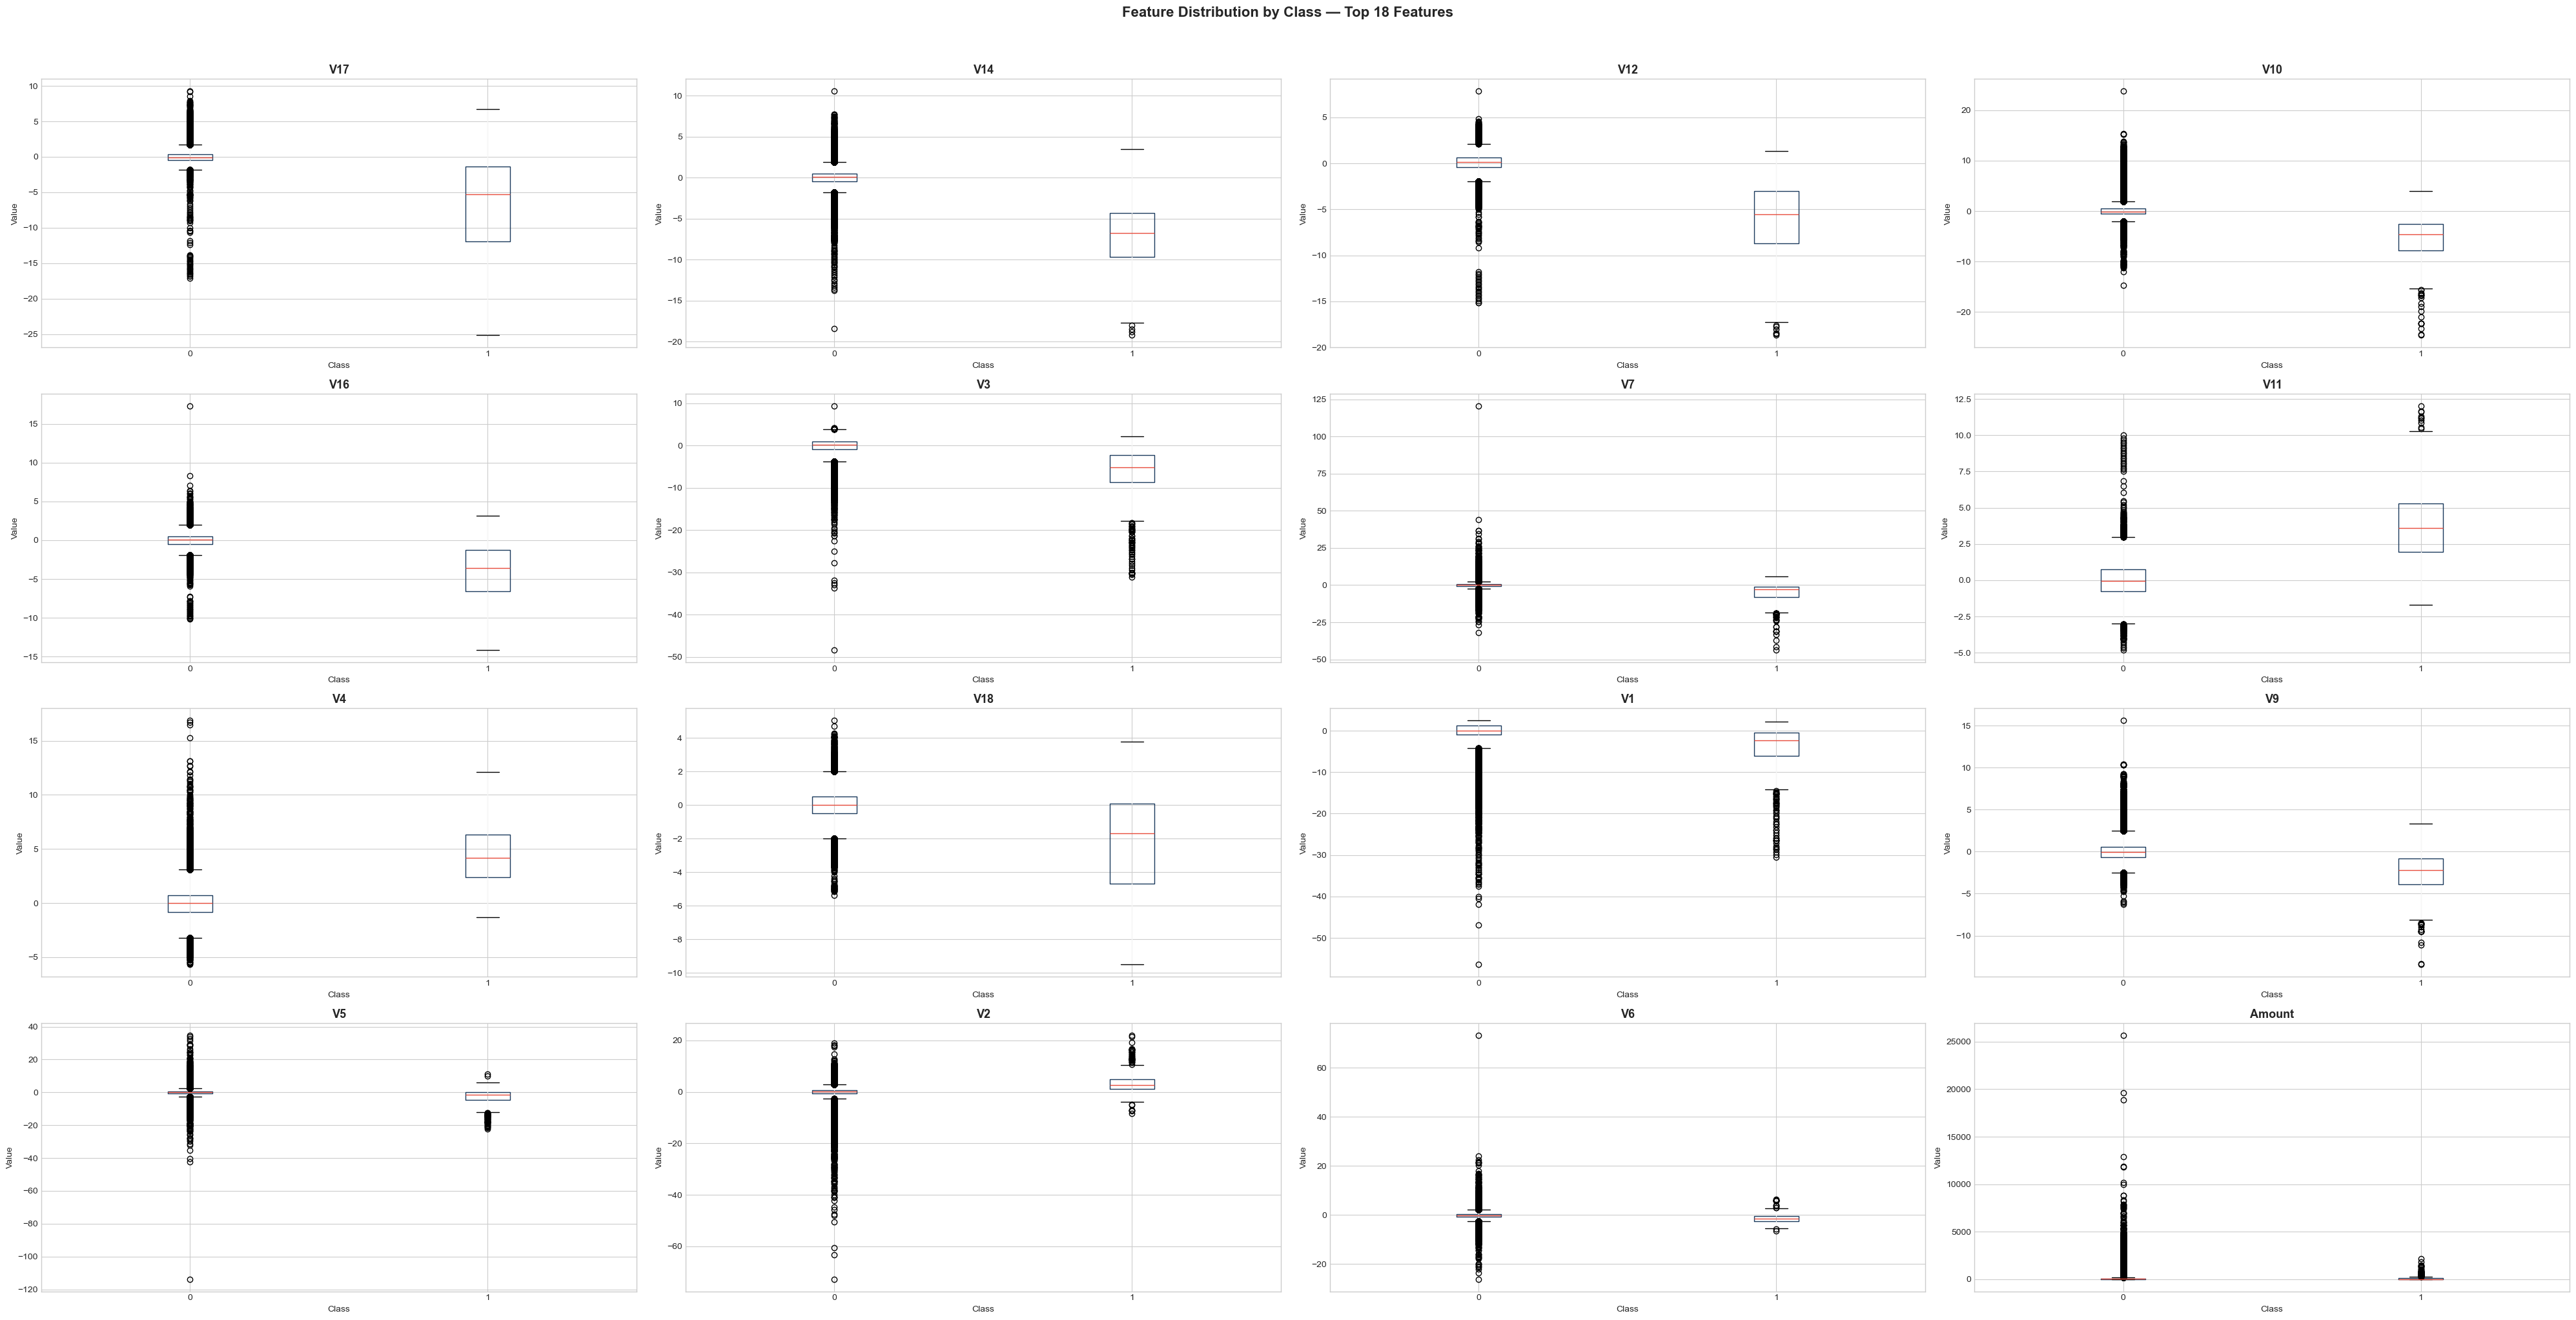

In [64]:
box_features = [col for col in top_cols if col not in ["Time", "Class"]]
fig, axes = plt.subplots(4, 4, figsize=(40, 20))
axes = axes.flatten()
for i, feat in enumerate(box_features):
    df.boxplot(column=feat, by="Class", ax=axes[i],
               boxprops=dict(color=COLORS["primary"]),
               medianprops=dict(color=COLORS["accent"]))
    axes[i].set_title(feat, fontsize=13, fontweight="bold")
    axes[i].set_xlabel("Class")
    axes[i].set_ylabel("Value")
plt.suptitle("Feature Distribution by Class — Top 18 Features", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/Box plot_key Features.png', dpi=150, bbox_inches='tight')
plt.show()

## EDA Summary 

### 1. Data Loading
- Loaded the Kaggle Credit Card Fraud Detection dataset (`data/creditcard.csv`)
- Dataset contains 284,807 transactions with 31 columns (Time, V1–V28, Amount, Class)
- Only 492 transactions (0.17%) are fraudulent - a severe class imbalance

### 2. Initial Data Inspection
- Checked dataset shape, data types, and basic statistics using `df.describe()`
- Verified no missing values in the dataset

### 3. Exploratory Data Analysis (EDA)
- **Class Distribution**: Pie chart confirmed the extreme 99.83% vs 0.17% imbalance
- **Amount Analysis**: Fraud transactions tend to have higher amounts (avg ~$122) compared to legitimate ones (avg ~$88), with the highest fraud at $2,125
- **Time Analysis**: Legitimate transactions follow day/night cycles while fraud is more randomly distributed
- **Correlation Heatmap**: Dynamically identified the top 8 features most correlated with fraud - V17, V14, V12, V10, V16, V3, V7, V11
- **Box Plots**: Visualized feature distributions by class for the top correlated features, confirming clear separation between fraud and legitimate patterns in key features
